In [36]:
import kagglehub
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.metrics import classification_report, confusion_matrix


In [37]:
path = Path(kagglehub.dataset_download("fanbyprinciple/iot-device-identification"))
data_train = pd.read_csv(path / "iot_device_train.csv")
data_test = pd.read_csv(path / "iot_device_test.csv")

In [38]:
print("Categories distribution (train):\n", data_train.device_category.value_counts())
print("\nCategories distribution (test):\n", data_test.device_category.value_counts())

data = pd.concat([data_train, data_test], ignore_index=True)
data = data.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nTotal combined samples: {data.shape}")
display(data.head())

Categories distribution (train):
 device_category
security_camera    100
TV                 100
smoke_detector     100
thermostat         100
water_sensor       100
watch              100
baby_monitor       100
motion_sensor      100
lights             100
socket             100
Name: count, dtype: int64

Categories distribution (test):
 device_category
baby_monitor       100
lights             100
motion_sensor      100
security_camera    100
smoke_detector     100
socket             100
thermostat         100
TV                 100
watch              100
Name: count, dtype: int64

Total combined samples: (1900, 298)


,ack,ack_A,ack_B,bytes,bytes_A,bytes_A_B_ratio,bytes_B,ds_field_A,ds_field_B,duration,...,suffix_is_co.il,suffix_is_com,suffix_is_com.sg,suffix_is_else,suffix_is_empty_char_value,suffix_is_googleapis.com,suffix_is_net,suffix_is_org,suffix_is_unresolved,device_category
0,48,18,30,1382,654,0.898350,728,0,0,1.7060,...,0,0,0,0,0,0,0,0,1,motion_sensor
1,9,5,5,1213,743,1.142203,668,0,0,0.7328,...,0,0,0,1,0,0,0,0,0,TV
2,9,5,5,1213,743,1.806874,668,0,0,1.5756,...,0,0,0,1,0,0,0,0,0,watch
3,9,5,5,1213,743,1.806874,668,0,0,1.5756,...,0,0,0,1,0,0,0,0,0,watch
4,12,6,6,1548,645,0.714285,903,0,0,0.8530,...,0,0,0,0,0,0,0,0,1,security_camera


In [39]:
missing = data.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if not missing.empty:
    plt.figure(figsize=(10, 6))
    missing.plot(kind='bar')
    plt.title("Missing values ​​per column")
    plt.ylabel("Amount")
    plt.tight_layout()
    plt.show()
else:
    print("There´s no missin values.")

There´s no missin values.


In [40]:
label_encoder = LabelEncoder()
data['device_category_encoded'] = label_encoder.fit_transform(data['device_category'])
print("\nCoded categories:")
for i, cat in enumerate(label_encoder.classes_):
    print(f"{i}: {cat}")


Coded categories:
0: TV
1: baby_monitor
2: lights
3: motion_sensor
4: security_camera
5: smoke_detector
6: socket
7: thermostat
8: watch
9: water_sensor


In [41]:
data_corr = data.drop(columns=["device_category"])
data_corr['device_category'] = data['device_category_encoded']

correlation = data_corr.corr().abs()
corr_target = correlation['device_category'].sort_values(ascending=False)
features_to_keep = corr_target[corr_target >= 0.1].index.tolist()
features_to_keep.remove('device_category')

print(f"\nSelected categories (corr ≥ 0.1): {len(features_to_keep)}")


Selected categories (corr ≥ 0.1): 94


In [42]:
X = data[features_to_keep]
y = data[['device_category']]

onehot_encoder = OneHotEncoder(sparse_output=False)
y_encoded = onehot_encoder.fit_transform(y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42)

In [45]:
def build_model(input_dim, output_dim):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(input_dim,)),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(output_dim, activation='softmax')
    ])
    model.compile(optimizer=Adam(0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

model = build_model(X_train.shape[1], y_train.shape[1])
model.summary()

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ModelCheckpoint("best_iot_model.h5", save_best_only=True)
]

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=callbacks,
    verbose=2
)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                     │ (None, 128)                 │          12,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_10 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_16 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_11 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_17 (Dense)                     │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 21,066 (82.29 KB)

 Trainable params: 21,066 (82.29 KB)

 Non-trainable params: 0 (0.00 B)

...

38/38 - 0s - 8ms/step - accuracy: 0.9737 - loss: 0.0990 - val_accuracy: 0.9868 - val_loss: 0.0748
Epoch 20/50
38/38 - 0s - 4ms/step - accuracy: 0.9696 - loss: 0.1122 - val_accuracy: 0.9868 - val_loss: 0.0765
Epoch 21/50


38/38 - 0s - 5ms/step - accuracy: 0.9745 - loss: 0.0963 - val_accuracy: 0.9868 - val_loss: 0.0717
Epoch 22/50
38/38 - 0s - 4ms/step - accuracy: 0.9803 - loss: 0.0849 - val_accuracy: 0.9836 - val_loss: 0.0774
Epoch 23/50


38/38 - 0s - 5ms/step - accuracy: 0.9844 - loss: 0.0846 - val_accuracy: 0.9901 - val_loss: 0.0670
Epoch 24/50
38/38 - 0s - 7ms/step - accuracy: 0.9811 - loss: 0.0702 - val_accuracy: 0.9836 - val_loss: 0.0723
Epoch 25/50


38/38 - 0s - 4ms/step - accuracy: 0.9770 - loss: 0.0983 - val_accuracy: 0.9901 - val_loss: 0.0663
Epoch 26/50
38/38 - 0s - 5ms/step - accuracy: 0.9836 - loss: 0.0682 - val_accuracy: 0.9868 - val_loss: 0.0663
Epoch 27/50
38/38 - 0s - 10ms/step - accuracy: 0.9844 - loss: 0.0719 - val_accuracy: 0.9868 - val_loss: 0.0706
Epoch 28/50


38/38 - 0s - 7ms/step - accuracy: 0.9803 - loss: 0.0711 - val_accuracy: 0.9868 - val_loss: 0.0641
Epoch 29/50
38/38 - 0s - 6ms/step - accuracy: 0.9852 - loss: 0.0662 - val_accuracy: 0.9868 - val_loss: 0.0658
Epoch 30/50
38/38 - 0s - 6ms/step - accuracy: 0.9852 - loss: 0.0610 - val_accuracy: 0.9868 - val_loss: 0.0655
Epoch 31/50
38/38 - 0s - 8ms/step - accuracy: 0.9885 - loss: 0.0517 - val_accuracy: 0.9836 - val_loss: 0.0745
Epoch 32/50
38/38 - 1s - 14ms/step - accuracy: 0.9836 - loss: 0.0611 - val_accuracy: 0.9836 - val_loss: 0.0671
Epoch 33/50
38/38 - 0s - 4ms/step - accuracy: 0.9844 - loss: 0.0494 - val_accuracy: 0.9836 - val_loss: 0.0686


In [ ]:
loss, acc = model.evaluate(X_test, y_test, verbose=0)

train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

print(f"\nFinal Training Accuracy: {train_acc:.4f}")
print(f"Final Validation Accuracy: {val_acc:.4f}")
print(f"Test Accuracy: {acc:.4f}")


Test accuracy: 0.9816


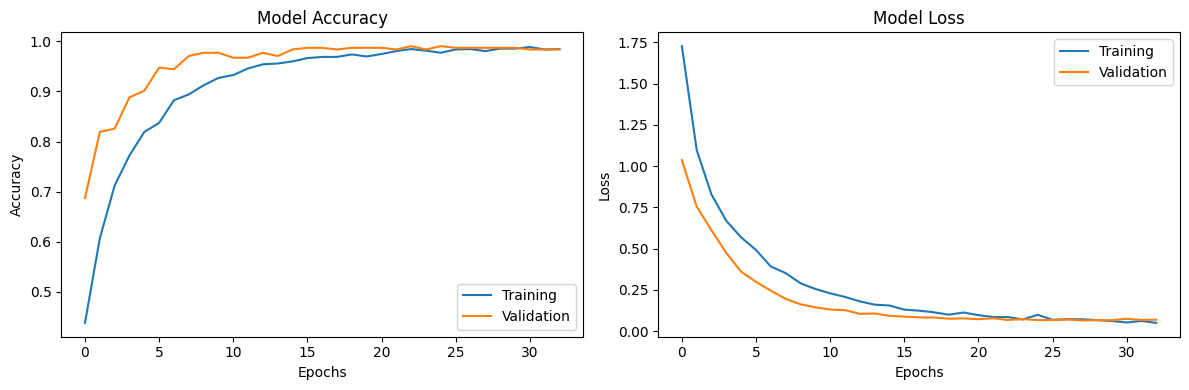

In [47]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training')
plt.plot(history.history['val_loss'], label='Validation')
plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 

Classification Report:
                 precision    recall  f1-score   support

             TV       0.97      1.00      0.98        31
   baby_monitor       1.00      0.97      0.99        36
         lights       0.97      1.00      0.99        34
  motion_sensor       0.98      0.98      0.98        41
security_camera       1.00      1.00      1.00        43
 smoke_detector       1.00      1.00      1.00        40
         socket       1.00      1.00      1.00        36
     thermostat       0.94      0.96      0.95        49
          watch       0.98      0.94      0.96        48
   water_sensor       1.00      1.00      1.00        22

       accuracy                           0.98       380
      macro avg       0.98      0.98      0.98       380
   weighted avg       0.98      0.98      0.98       380



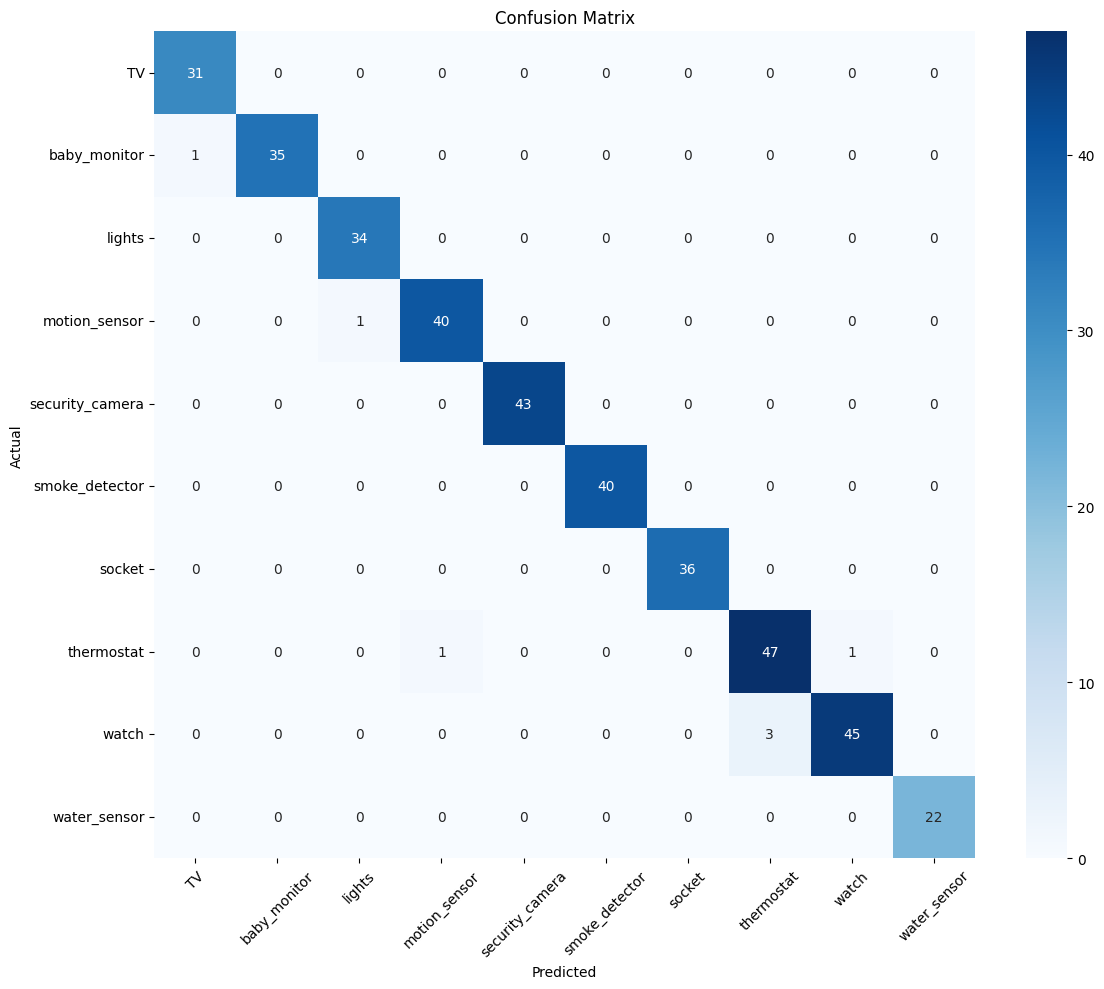

In [48]:
y_pred = model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

print("\nClassification Report:")
print(classification_report(y_true_labels, y_pred_labels, target_names=onehot_encoder.categories_[0]))

cm = confusion_matrix(y_true_labels, y_pred_labels)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=onehot_encoder.categories_[0],
            yticklabels=onehot_encoder.categories_[0])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [49]:
sample_idx = 5
probs = y_pred[sample_idx]
print(f"\nPrediction probabilities for sample {sample_idx}:")

for i, prob in enumerate(probs):
    print(f"Class {i} ({onehot_encoder.categories_[0][i]}): {prob:.4f}")

print(f"Predicted class: {onehot_encoder.categories_[0][np.argmax(probs)]}")
print(f"Actual class: {onehot_encoder.categories_[0][y_true_labels[sample_idx]]}")

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42)


Prediction probabilities for sample 5:
Class 0 (TV): 0.0000
Class 1 (baby_monitor): 0.0000
Class 2 (lights): 0.0000
Class 3 (motion_sensor): 0.0001
Class 4 (security_camera): 0.0006
Class 5 (smoke_detector): 0.0000
Class 6 (socket): 0.0000
Class 7 (thermostat): 0.9962
Class 8 (watch): 0.0030
Class 9 (water_sensor): 0.0001
Predicted class: thermostat
Actual class: thermostat
